In [ ]:
import pandas as pd 
import numpy as np

from sklearn.model_selection import  train_test_split
# from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

# Final Statement of Day 9 
A probability-threshold calibrated classifier was implemented to address class imbalance in Buy/Hold/Sell predictions. Instead of relying on default argmax decision rules, dynamic thresholds proportional to maximum predicted class probability were applied. This improved minority class recall while maintaining overall accuracy stability (~82%) and improved macro F1-score (~0.54).
That sounds professional and strong.**

In [ ]:
df = pd.read_csv("../data/day_7.csv")
print(df.shape)
print(df.columns)

(1480, 23)
Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Returns',
       'Rolling Mean', 'Rolling Volatility', 'Cumulative Return', 'Fear_Greed',
       'Risk_Adjustment_Returns', 'Fear_Signal', 'Investor_Bias',
       'Recommendataion', 'sharpe_Rato', 'Rolling_Sharpe', 'Performance',
       'Recommendation', 'Strategy_Return', 'Cumulative_Strategy_Return',
       'Cumulative_Market_Return', 'Recommendation_Shifted'],
      dtype='object')


In [ ]:
df=df.copy()

df['Momentum'] = df['Close']-df['Close'].shift(5)

df['MA_Short'] = df['Close'].rolling(window=5).mean()
df['MA_Long'] =  df['Close'].rolling(window=20).mean()

df['MA_crossover'] = np.where(df['MA_Short'] > df['MA_Long'],1,0)

df['Volatility_Change'] = df['Rolling Volatility'].pct_change()

df['Prince_Change']=df['Close'].pct_change()




In [ ]:
df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Returns',
       'Rolling Mean', 'Rolling Volatility', 'Cumulative Return', 'Fear_Greed',
       'Risk_Adjustment_Returns', 'Fear_Signal', 'Investor_Bias',
       'Recommendataion', 'sharpe_Rato', 'Rolling_Sharpe', 'Performance',
       'Recommendation', 'Strategy_Return', 'Cumulative_Strategy_Return',
       'Cumulative_Market_Return', 'Recommendation_Shifted', 'Momentum',
       'MA_Short', 'MA_Long', 'MA_crossover', 'Volatility_Change',
       'Prince_Change'],
      dtype='object')

In [ ]:
df[['Momentum',
       'MA_Short', 'MA_Long', 'MA_crossover', 'Volatility_Change',
       'Prince_Change']].head(10)

,Momentum,MA_Short,MA_Long,MA_crossover,Volatility_Change,Prince_Change
0,NaN,NaN,NaN,0,NaN,NaN
1,NaN,NaN,NaN,0,NaN,-0.002225
2,NaN,NaN,NaN,0,NaN,0.002992
3,NaN,NaN,NaN,0,NaN,0.006435
4,NaN,40.795650,NaN,0,NaN,-0.005639
5,0.517555,40.899162,NaN,0,NaN,0.011166
6,0.908688,41.080899,NaN,0,NaN,0.007284
7,0.810917,41.243082,NaN,0,NaN,0.000574
8,0.677357,41.378554,NaN,0,NaN,0.003098
9,0.498470,41.478248,NaN,0,NaN,-0.009836


In [ ]:
df.rename(columns={'Prince_Change':'Price_Change'},inplace=True)

In [ ]:
ml_data = df.dropna()

print("Shape Before Cleaning ",df.shape)

print("Shape after cleaning",ml_data.shape)

Shape Before Cleaning  (1480, 29)
Shape after cleaning (1422, 29)


In [ ]:
features = ['Momentum',
       'MA_Short', 
       'MA_Long', 
       'MA_crossover',
       'Volatility_Change',
       'Price_Change',
       'Rolling Volatility',
       'Rolling Mean', 
       'Volume']

x = ml_data[features]
y = ml_data['Recommendation_Shifted']


print("x Shape:",x.shape)
print("y Shape:",y.shape)

print("Target values : ",y.unique())

x Shape: (1422, 9)
y Shape: (1422,)
Target values :  ['Sell' 'Hold' 'Buy']


In [ ]:
# ==============================
# 1️⃣ Import Libraries
# ==============================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

from xgboost import XGBClassifier


# ==============================
# 2️⃣ Train-Test Split
# ==============================

x_train, x_test, y_train, y_test = train_test_split(
    x ,y,                # your features and labels
    test_size=0.2,
    random_state=42,
    stratify=y           # VERY IMPORTANT for imbalance
)


# ==============================
# 3️⃣ Encode Labels
# ==============================

encoder = LabelEncoder()

y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded  = encoder.transform(y_test)


# ==============================
# 4️⃣ Build XGBoost Model
# ==============================

model = XGBClassifier(
    n_estimators=600,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=1,
    min_child_weight=3,
    reg_alpha=0.3,
    reg_lambda=1,
    objective='multi:softprob',   # important
    num_class=3,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)


# ==============================
# 5️⃣ Train Model
# ==============================

model.fit(x_train, y_train_encoded)


# ==============================
# 6️⃣ Predict on Test Data
# ==============================

y_pred_encoded = model.predict(x_test)

# Convert back to original labels (Buy, Hold, Sell)
y_pred = encoder.inverse_transform(y_pred_encoded)


# ==============================
# 7️⃣ Evaluation
# ==============================

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nPrediction Counts:")
print(pd.Series(y_pred).value_counts())

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8245614035087719

Prediction Counts:
Hold    267
Buy      10
Sell      8
Name: count, dtype: int64

Classification Report:
              precision    recall  f1-score   support

         Buy       0.40      0.15      0.22        26
        Hold       0.86      0.95      0.90       241
        Sell       0.25      0.11      0.15        18

    accuracy                           0.82       285
   macro avg       0.50      0.41      0.43       285
weighted avg       0.78      0.82      0.79       285


Confusion Matrix:
[[  4  22   0]
 [  6 229   6]
 [  0  16   2]]


In [39]:
buy_threshold = 0.35 * probs_df["Buy"].max()
sell_threshold = 0.5 * probs_df["Sell"].max()

print(buy_threshold, sell_threshold)

predictions = []

for probs in y_prob:
    buy_prob  = probs[0]
    sell_prob = probs[2]
    
    if buy_prob > buy_threshold:
        predictions.append("Buy")
    elif sell_prob > sell_threshold:
        predictions.append("Sell")
    else:
        predictions.append("Hold")

y_pred = np.array(predictions)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

0.27592808604240415 0.35011380910873413
Accuracy: 0.8175438596491228
              precision    recall  f1-score   support

         Buy       0.38      0.31      0.34        26
        Hold       0.88      0.90      0.89       241
        Sell       0.41      0.39      0.40        18

    accuracy                           0.82       285
   macro avg       0.56      0.53      0.54       285
weighted avg       0.81      0.82      0.81       285

[[  8  18   0]
 [ 13 218  10]
 [  0  11   7]]


In [42]:
df_test = df.loc[x_test.index].copy()
df_test['predictions']=y_pred
df_test[['predictions']].head()

,predictions
825,Hold
1477,Hold
407,Hold
1192,Hold
334,Hold


In [45]:
df_test["Model_Strategy_Return"] = 0

df_test.loc[df_test["predictions"] == "Buy", "Model_Strategy_Return"] = df_test["Returns"]

df_test.loc[df_test["predictions"] == "Sell", "Model_Strategy_Return"] = -df_test["Returns"]

C:\Users\famil\AppData\Local\Temp\ipykernel_23332\190564302.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 0.00098828  0.01319187  0.00673702  0.00509084  0.03032576 -0.01669317
  0.01922044 -0.00448032  0.00041965  0.0001162   0.0210996  -0.00194752
 -0.03091039 -0.00156037  0.00066167  0.01453479 -0.01269152  0.00257014
 -0.01227438  0.00696364  0.00902075]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_test.loc[df_test["predictions"] == "Buy", "Model_Strategy_Return"] = df_test["Returns"]


In [44]:
df_test.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Returns',
       'Rolling Mean', 'Rolling Volatility', 'Cumulative Return', 'Fear_Greed',
       'Risk_Adjustment_Returns', 'Fear_Signal', 'Investor_Bias',
       'Recommendataion', 'sharpe_Rato', 'Rolling_Sharpe', 'Performance',
       'Recommendation', 'Strategy_Return', 'Cumulative_Strategy_Return',
       'Cumulative_Market_Return', 'Recommendation_Shifted', 'Momentum',
       'MA_Short', 'MA_Long', 'MA_crossover', 'Volatility_Change',
       'Price_Change', 'predictions', 'Model_Strategy_Return'],
      dtype='object')

In [46]:
df_test["Model_Strategy_Return"] = 0

df_test.loc[df_test["predictions"] == "Buy", "Model_Strategy_Return"] = df_test["Returns"]

df_test.loc[df_test["predictions"] == "Sell", "Model_Strategy_Return"] = -df_test["Returns"]

C:\Users\famil\AppData\Local\Temp\ipykernel_23332\190564302.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 0.00098828  0.01319187  0.00673702  0.00509084  0.03032576 -0.01669317
  0.01922044 -0.00448032  0.00041965  0.0001162   0.0210996  -0.00194752
 -0.03091039 -0.00156037  0.00066167  0.01453479 -0.01269152  0.00257014
 -0.01227438  0.00696364  0.00902075]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_test.loc[df_test["predictions"] == "Buy", "Model_Strategy_Return"] = df_test["Returns"]


In [47]:
df_test["Cumulative_Model_Return"] = (1 + df_test["Model_Strategy_Return"]).cumprod()

df_test["Cumulative_Market_Return"] = (1 + df_test["Returns"]).cumprod()

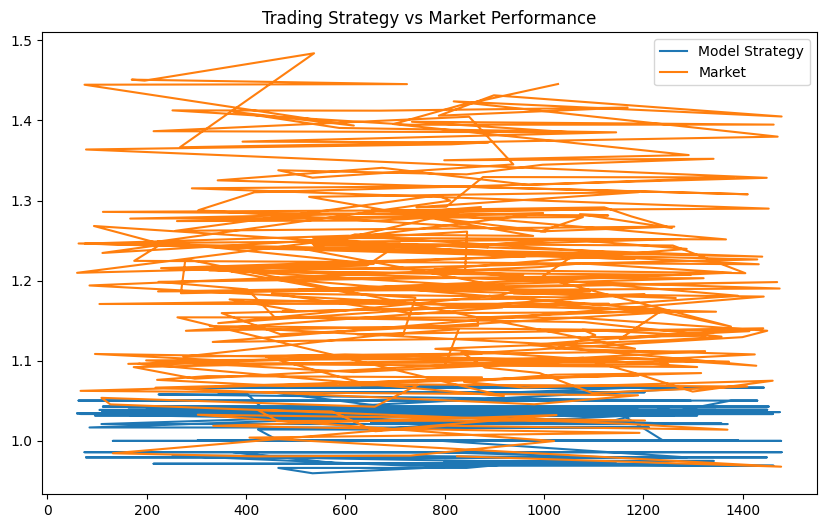

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(df_test["Cumulative_Model_Return"], label="Model Strategy")

plt.plot(df_test["Cumulative_Market_Return"], label="Market")

plt.title("Trading Strategy vs Market Performance")

plt.legend()

plt.show()

In [49]:
df_test = df_test.sort_index()

In [50]:
df_test["Cumulative_Model_Return"] = (1 + df_test["Model_Strategy_Return"]).cumprod()

df_test["Cumulative_Market_Return"] = (1 + df_test["Returns"]).cumprod()

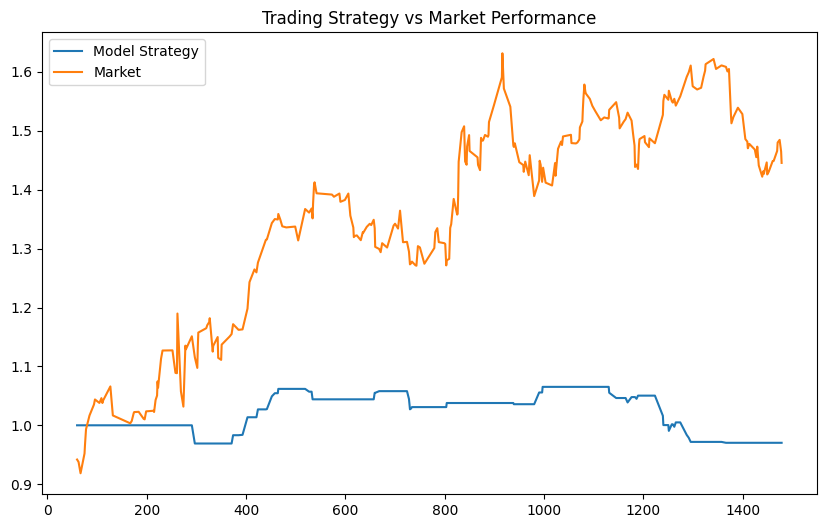

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(df_test["Cumulative_Model_Return"], label="Model Strategy")

plt.plot(df_test["Cumulative_Market_Return"], label="Market")

plt.title("Trading Strategy vs Market Performance")

plt.legend()

plt.show()

In [52]:
strategy_return = df_test["Cumulative_Model_Return"].iloc[-1] - 1
market_return = df_test["Cumulative_Market_Return"].iloc[-1] - 1

print("Strategy Total Return:", strategy_return)
print("Market Total Return:", market_return)

Strategy Total Return: -0.02971133091261291
Market Total Return: 0.4455067567795985


In [53]:
sharpe_ratio = df_test["Model_Strategy_Return"].mean() / df_test["Model_Strategy_Return"].std()

print("Sharpe Ratio:", sharpe_ratio)

Sharpe Ratio: -0.019792872896705376


In [54]:
rolling_max = df_test["Cumulative_Model_Return"].cummax()

drawdown = (df_test["Cumulative_Model_Return"] - rolling_max) / rolling_max

max_drawdown = drawdown.min()

print("Maximum Drawdown:", max_drawdown)


Maximum Drawdown: -0.08914549829710336
